In [4]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import tensorflow as tf

import tensorflow as tf
print(tf.config.list_physical_devices())

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## 1. reading and analyzing data

In [5]:
df=pd.read_csv('complaints_processed.csv')
df.head()

,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...
3,3,credit_reporting,payment history missing credit report speciali...
4,4,credit_reporting,payment history missing credit report made mis...


In [6]:
# dropping S.no column
df.drop(columns=['Unnamed: 0'],axis=1,inplace=True)
df.rename(columns={'narrative':'complaints'},inplace=True)
df.head()

,product,complaints
0,credit_card,purchase order day shipping amount receive pro...
1,credit_card,forwarded message date tue subject please inve...
2,retail_banking,forwarded message cc sent friday pdt subject f...
3,credit_reporting,payment history missing credit report speciali...
4,credit_reporting,payment history missing credit report made mis...


In [7]:
# Analysing dataframe attributes 
print('* Size of dataframe: {}\n'.format(df.shape))
print('* Datatype of columns are:\n {}\n'.format(df.dtypes))
print('* Count of different product categories:\n {}\n'.format(df['product'].value_counts()))
print('* Number of NaNs among complaints are: {}\n'.format(df['complaints'].isnull().sum())) 

* Size of dataframe: (162421, 2)

* Datatype of columns are:
 product       object
complaints    object
dtype: object

* Count of different product categories:
 product
credit_reporting       91179
debt_collection        23150
mortgages_and_loans    18990
credit_card            15566
retail_banking         13536
Name: count, dtype: int64

* Number of NaNs among complaints are: 10



In [8]:
# Removing NaNs
df = df.dropna(subset=['complaints'])
print('NaNs are removed from the dataframe. Number of NaNs can be confirmed to be {}. The size of dataframe has reduced to {}'.format(df['complaints'].isnull().sum(), df.shape))

NaNs are removed from the dataframe. Number of NaNs can be confirmed to be 0. The size of dataframe has reduced to (162411, 2)


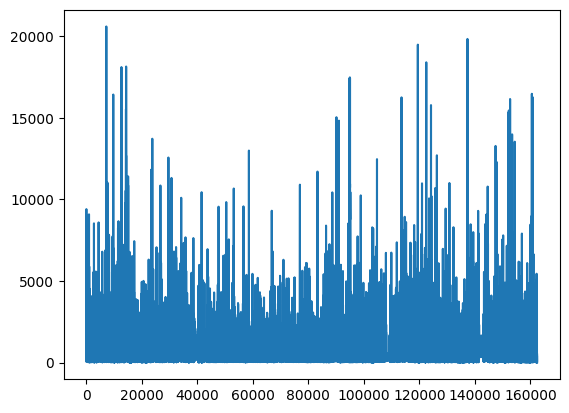

In [9]:
# Plotting word lengths of complaints
word_length = [len(x) for x in df['complaints']]
plt.plot(word_length)

In [10]:
# Converting sentences to string
df['complaints'] = df['complaints'].astype(str)

In [11]:
# Types of products
df['product'].value_counts()

product
credit_reporting       91172
debt_collection        23148
mortgages_and_loans    18990
credit_card            15566
retail_banking         13535
Name: count, dtype: int64

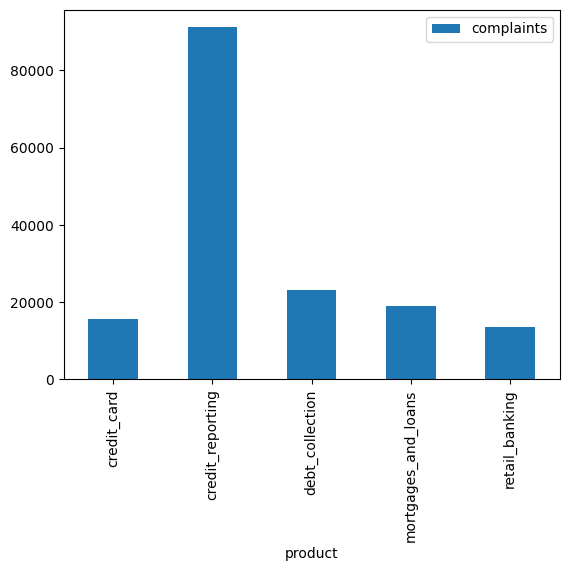

In [12]:
# Plotting product value counts
df.groupby('product').count().plot(kind='bar')
plt.show()

## 2. train-test split

In [13]:
# Importing train test splilt library 
from sklearn.model_selection import train_test_split

# Train-Test Splitting
train_data, test_data = train_test_split(df, test_size = 0.20)

In [14]:
# Train and test data dimensions
train_data.shape, test_data.shape

((129928, 2), (32483, 2))

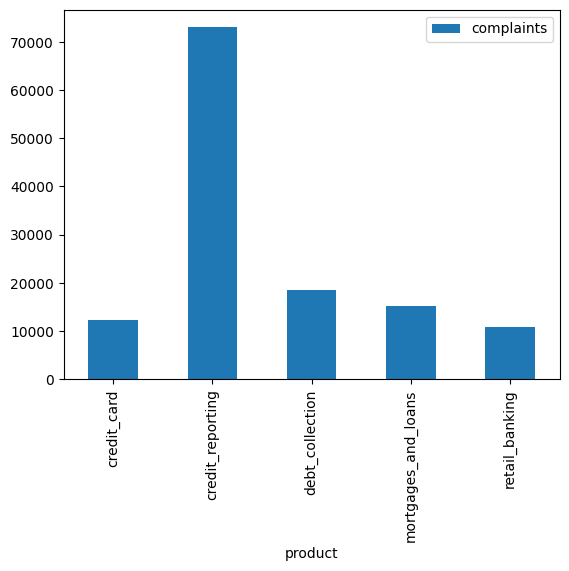

In [15]:
# Balance of train data
train_data.groupby('product').count().plot(kind='bar')
plt.show()

credit_card, debt_collection, mortgages_and_loans, retail_banking columns consist of very few values. So, the values in these columns will be increased using random oversampling.
Oversampling is done in train set because this will prevent data leakage to test set.

## 3. random oversampling

In [16]:
# Train set value counts 
train_data.groupby('product').count()

,complaints
product,
credit_card,12410
credit_reporting,72995
debt_collection,18516
mortgages_and_loans,15176
retail_banking,10831


In [17]:
# Randomly selecting 7000 indices in classes with low value count
import numpy as np
to_add_1 = np.random.choice(train_data[train_data['product']=='credit_card'].index,size = 7000,replace=False)   
to_add_2 = np.random.choice(train_data[train_data['product']=='debt_collection'].index,size = 7000,replace=False) 
to_add_3 = np.random.choice(train_data[train_data['product']=='mortgages_and_loans'].index,size = 7000,replace=False)  
to_add_4 = np.random.choice(train_data[train_data['product']=='retail_banking'].index,size=7000,replace=False)

# Indices to be added
to_add = np.concatenate((to_add_1, to_add_2, to_add_3, to_add_4 ))
len(to_add)

28000

In [18]:
# Forming a dataframe for randomly selected indices
df_replicate = train_data[train_data.index.isin(to_add)]
df_replicate  

,product,complaints
118454,debt_collection,paid debt brett borland pc law firm week ago s...
70754,credit_card,received direct deposit michigan unemployment ...
111830,debt_collection,wrote portfolio recovery account unknown amoun...
103795,debt_collection,friday called asset care dispute debt appears ...
111894,credit_card,capital one credit card debit card used store ...
...,...,...
75099,credit_card,reviewed statement month reward balance droppe...
17221,mortgages_and_loans,email executive office thu year mortgage chase...
30413,mortgages_and_loans,currently enrolled school information submitte...
78803,mortgages_and_loans,totalled car quality acceptance paid put left ...


In [19]:
# Concatenating replicated df to orinigal df
train_data = pd.concat([train_data, df_replicate])
train_data['product'].value_counts()

product
credit_reporting       72995
debt_collection        25516
mortgages_and_loans    22176
credit_card            19410
retail_banking         17831
Name: count, dtype: int64

Value counts of minority classes have increased.

## 4. test preprocessing

In [20]:
# Importing NLTK Libraries
import nltk
from nltk.corpus import stopwords
from nltk import *

In [21]:
# Declaring function for text preprocessing 

def preprocess_text(main_df):
  df_1 = main_df.copy()

  # remove stopwords
  nltk.download('stopwords')         # Downloading stopwords
  stop = stopwords.words('english')  
  df_1['complaints'] = df_1['complaints'].apply(lambda x: " ".join(x for x in x.split() if x not in stop)) 
  
  # remove punctuations and convert to lower case
  df_1['complaints'] = df_1['complaints'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x).lower())

  # remove double spaces
  df_1['complaints'] = df_1['complaints'].apply(lambda x: re.sub(' ', ' ', x))

  return df_1  

In [22]:
train_data['complaints'].isna().sum()
train_data = train_data.dropna(subset=['complaints'])
test_data['complaints'].isna().sum()
test_data = test_data.dropna(subset=['complaints'])

In [23]:
# Preprocessing training and test data 
train_data = preprocess_text(train_data)
test_data = preprocess_text(test_data)

[nltk_data] Downloading package stopwords to /Users/oscar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/oscar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [24]:
train_data.head()

,product,complaints
118454,debt_collection,paid debt brett borland pc law firm week ago s...
70754,credit_card,received direct deposit michigan unemployment ...
92487,credit_reporting,ive attempted item removed sent letter company...
148056,credit_reporting,never able get contact original creditor alleg...
56308,retail_banking,citibank personal checking account year citiba...


## 5. label encoding

In [25]:
# Declaring train labels
train_labels = train_data['product'] 
test_labels = test_data['product']

In [26]:
# Converting labels to numerical features
import numpy as np
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(train_labels)
train_labels = le.transform(train_labels)
test_labels = le.transform(test_labels)

print(le.classes_)
print(np.unique(train_labels, return_counts=True))
print(np.unique(test_labels, return_counts=True))

['credit_card' 'credit_reporting' 'debt_collection' 'mortgages_and_loans'
 'retail_banking']
(array([0, 1, 2, 3, 4]), array([19410, 72995, 25516, 22176, 17831]))
(array([0, 1, 2, 3, 4]), array([ 3156, 18177,  4632,  3814,  2704]))


In [27]:
# Changing labels to categorical features
import numpy as np
from tensorflow.python.keras.utils import np_utils
from tensorflow.keras.utils import to_categorical
import numpy as np

train_labels = to_categorical(np.asarray(train_labels))
test_labels = to_categorical(np.array(test_labels))

## 6. tokenizing sentences and fixing sentence length

In [29]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Defining training parameters
max_sequence_length = 170   
max_words = 2500   

# Tokenizing tweets/sentences wrt num_words
tokenizer = Tokenizer(num_words = max_words)  # Selects most frequent words 
tokenizer.fit_on_texts(train_data.complaints)      # Develops internal vocab based on training text
train_sequences = tokenizer.texts_to_sequences(train_data.complaints)  # converts text to sequence

test_sequences = tokenizer.texts_to_sequences(test_data.complaints)

In [30]:
# Fixing the sequence length 
from tensorflow.keras.preprocessing.sequence import pad_sequences
train_data = pad_sequences(train_sequences, maxlen = max_sequence_length)
test_data = pad_sequences(test_sequences, maxlen = max_sequence_length)
train_data.shape, test_data.shape

((157928, 170), (32483, 170))

## 7. Bi-LSTM Model

In [31]:
# Model Parameters
embedding_dim = 32  

In [32]:
# Importing Libraries

import tensorflow as tf
import sys, os, re, csv, codecs, numpy as np, pandas as pd
from tensorflow.keras.layers import Dense, Input, LSTM, Embedding, Dropout, Activation
from tensorflow.keras.layers import Bidirectional, GlobalMaxPool1D, Conv1D, SimpleRNN
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras import initializers, regularizers, constraints, optimizers, layers
from tensorflow.keras.layers import Dense, Input, Input, Flatten, Dropout, BatchNormalization
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Embedding 

In [33]:
embedding_dim = 32  

# Model Training
model = Sequential()
model.add(Embedding(max_words, 
                   embedding_dim,
                   input_length=max_sequence_length))

# Bidirectional LSTM 
model.add(Bidirectional(LSTM(16, return_sequences=True, dropout=0.4, recurrent_dropout=0)))   

model.add(GlobalMaxPool1D())

model.add(Dense(5,activation='softmax'))  

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 170, 32)           80000     
                                                                 
 bidirectional (Bidirection  (None, 170, 32)           6272      
 al)                                                             
                                                                 
 global_max_pooling1d (Glob  (None, 32)                0         
 alMaxPooling1D)                                                 
                                                                 
 dense (Dense)               (None, 5)                 165       
                                                                 
Total params: 86437 (337.64 KB)
Trainable params: 86437 (337.64 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [34]:
model.compile(loss = 'binary_crossentropy', optimizer='RMSProp', metrics = ['accuracy'])  

In [35]:
# declaring weights of product categories
class_weight = {0: 4,          
                1: 5,    
                2: 3,      
                3: 3,     
                4: 4}      

# training and validating model 
history = model.fit(train_data, train_labels, batch_size=48, epochs= 20, class_weight = class_weight, validation_data=(test_data, test_labels)) # best 89(now) or 48 or 60 epochs # default epochs = 23 # batch_size changed to 1 (takes 2.30hrs) from 16

Epoch 1/20
3291/3291 [==============================] - 57s 17ms/step - loss: 0.9251 - accuracy: 0.7389 - val_loss: 0.1563 - val_accuracy: 0.8526
Epoch 2/20
3291/3291 [==============================] - 56s 17ms/step - loss: 0.5971 - accuracy: 0.8500 - val_loss: 0.1429 - val_accuracy: 0.8640
Epoch 3/20
3291/3291 [==============================] - 56s 17ms/step - loss: 0.5628 - accuracy: 0.8574 - val_loss: 0.1416 - val_accuracy: 0.8665
Epoch 4/20
3291/3291 [==============================] - 57s 17ms/step - loss: 0.5486 - accuracy: 0.8618 - val_loss: 0.1392 - val_accuracy: 0.8695
Epoch 5/20
3284/3291 [============================>.] - ETA: 0s - loss: 0.5392 - accuracy: 0.8647

KeyboardInterrupt: 

In [ ]:
# Prediction on Test Data
predicted_bi_lstm = model.predict(test_data)
predicted_bi_lstm

## 8. Model evaluation

In [ ]:
import sklearn
from sklearn.metrics import precision_recall_fscore_support as score
precision, recall, fscore, support = score(test_labels, predicted_bi_lstm.round())

print('precision: {}'.format(precision))
print('recall: {}'.format(recall))
print('fscore: {}'.format(fscore))
print('support: {}'.format(support))
print('################################')
print(sklearn.metrics.classification_report(test_labels, predicted_bi_lstm.round()))

In [ ]:
def accuracy_plot(history):
    
    fig, ax = plt.subplots(1, 2, figsize=(12,5))
    
    fig.suptitle('Model Performance with Epochs', fontsize = 16)
    # Subplot 1 
    ax[0].plot(history.history['accuracy'])
    ax[0].plot(history.history['val_accuracy'])
    ax[0].set_title('Model Accuracy', fontsize = 14)
    ax[0].set_xlabel('Epochs', fontsize = 12)
    ax[0].set_ylabel('Accuracy', fontsize = 12)
    ax[0].legend(['train', 'validation'], loc='best')
    
    # Subplot 2
    ax[1].plot(history.history['loss'])
    ax[1].plot(history.history['val_loss'])
    ax[1].set_title('Model Loss', fontsize = 14)
    ax[1].set_xlabel('Epochs', fontsize = 12)
    ax[1].set_ylabel('Loss', fontsize = 12)
    ax[1].legend(['train', 'validation'], loc='best')
    
    
accuracy_plot(history)


In [ ]:
# Declaring function for plotting confusion matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_cm(model, test_data, test_labels):
    
    products = ['Credit Card', 'Credit Reporting', 'Debt Collection', 'Mortgages \nand Loans', 'Retail Banking']
        
    # Calculate predictions
    pred = model.predict(test_data)
    
    # Declaring confusion matrix
    cm = confusion_matrix(np.argmax(np.array(test_labels),axis=1), np.argmax(pred, axis=1))

    # Heat map labels

    group_counts = ['{0:0.0f}'.format(value) for value in cm.flatten()]
    group_percentages = ['{0:.2%}'.format(value) for value in cm.flatten()/np.sum(cm)]
    
    labels = [f"{v2}\n{v3}" for v2, v3 in zip(group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(5,5)

    # Plotting confusion matrix
    plt.figure(figsize=(12,8))
    
    sns.heatmap(cm, cmap=plt.cm.Blues, annot=labels, annot_kws={"size": 15}, fmt = '',
                xticklabels = products,
                yticklabels = products)
    
    plt.xticks(fontsize = 12)
    plt.yticks(fontsize = 12, rotation = 'horizontal')
    plt.title('Confusion Matrix\n', fontsize=19)
    plt.xlabel('Predicted Labels', fontsize=17)
    plt.ylabel('Actual Labels', fontsize=17)
    
plot_cm(model, test_data, test_labels)

